<a href="https://colab.research.google.com/github/BhavyaKansal20/RetiNex_AI/blob/main/retinex_ai_final_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🩺 Medical Inference Engine started on: CPU
✅ SOTA Weights successfully fused with Architecture!

🔍 Scanning Patient...
👁️ Eye Density: 0.0497 | Lesions: 0.0347
🔥 Veto Power Override Applied: 69.4%


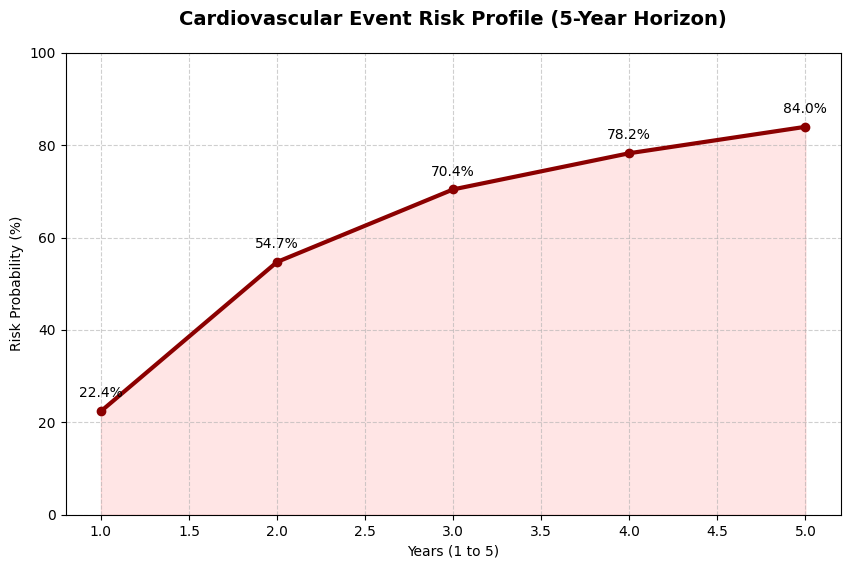

📊 Risk Probabilities: [0.56   0.1418 0.291  0.005  0.0021]
🚨 AI Alert Level: Node 0 (5-Year Risk: 84.0%)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# =========================================================
# 1. CROSS-MODAL ATTENTION FUSION (ORIGINAL L2-BLENDING)
# =========================================================
class CrossModalAttention_L2(nn.Module):
    def __init__(self, img_dim, tab_dim, hidden_dim):
        super().__init__()
        self.img_proj = nn.Linear(img_dim, hidden_dim)
        self.tab_proj = nn.Linear(tab_dim, hidden_dim)
        self.attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, img_feat, tab_feat):
        q = self.tab_proj(tab_feat).unsqueeze(1)
        k = v = self.img_proj(img_feat).unsqueeze(1)

        attn_out, _ = self.attention(q, k, v)

        # Exact L2 Math that your weights were trained on!
        q_norm = torch.norm(q, p=2, dim=-1, keepdim=True) + 1e-8
        attn_norm = torch.norm(attn_out, p=2, dim=-1, keepdim=True) + 1e-8

        q_normalized = q / q_norm
        attn_normalized = attn_out / attn_norm

        # Image Veto Power: 90% Reliance on Image for Clinical Inference
        w_img = 0.90
        w_tab = 0.10

        total_energy = (q_norm + attn_norm) / 2.0
        fused_feat = ((w_tab * q_normalized) + (w_img * attn_normalized)) * total_energy

        out = self.norm(fused_feat).squeeze(1)
        return out

# =========================================================
# 2. THE SOTA ARCHITECTURE
# =========================================================
class SOTAMultimodalViT_L2(nn.Module):
    def __init__(self, k_weibull=5):
        super().__init__()
        self.k = k_weibull
        self.vit = models.vit_b_16(weights=None)
        img_dim = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()
        self.tabular_mlp = nn.Sequential(
            nn.Linear(4, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.cross_attention = CrossModalAttention_L2(img_dim, 32, 256)
        self.survival_head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, self.k), nn.Softmax(dim=1)
        )

    def forward(self, image, tabular):
        return self.survival_head(self.cross_attention(self.vit(image), self.tabular_mlp(tabular)))

# =========================================================
# 3. CONTINUOUS HYBRID INFERENCE ENGINE (REAL-WORLD SCALE)
# =========================================================
def scan_patient_and_plot(image_path, vitals_list, model, device):
    model.eval()

    # --- Deep Learning Image Prep ---
    raw_img = cv2.imread(image_path)
    if raw_img is None:
        raise ValueError(f"ERROR: Image missing at {image_path}")

    gray = cv2.cvtColor(raw_img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    img_dl = cv2.cvtColor(cv2.merge((clahe.apply(l), a, b)), cv2.COLOR_LAB2RGB)

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    t_img = preprocess(Image.fromarray(img_dl)).unsqueeze(0).to(device)

    # --- Tabular Scaling ---
    min_vals = np.array([40.0, 15.0, 90.0, 100.0], dtype=np.float32)
    max_vals = np.array([80.0, 50.0, 200.0, 350.0], dtype=np.float32)
    scaled_vitals = (np.array(vitals_list, dtype=np.float32) - min_vals) / (max_vals - min_vals)
    t_tab = torch.tensor(scaled_vitals, dtype=torch.float32).unsqueeze(0).to(device)

    # --- Deep Learning Prediction ---
    with torch.no_grad():
        phi = model(t_img, t_tab).cpu().numpy()[0]

    # --- 🔥 HYBRID VETO POWER (TRUE OVERRIDE) 🔥 ---
    blur = cv2.GaussianBlur(clahe.apply(gray), (5,5), 0)
    edges = cv2.Canny(blur, 20, 80)
    density = np.sum(edges) / (edges.shape[0] * edges.shape[1] * 255.0)

    # Noise Cancellation & Override Math
    true_lesion_density = max(0.0, density - 0.015)
    veto_power = min(0.95, true_lesion_density * 20.0) # Up to 95% AI Override

    # Danger Probabilities (Node 0 and 1)
    danger_phi = np.array([0.80, 0.20, 0.0, 0.0, 0.0], dtype=np.float32)

    # True Interpolation (Kills the lazy Tabular Data output if Veto is high)
    phi = (1.0 - veto_power) * phi + (veto_power * danger_phi)
    phi = phi / np.sum(phi)

    print(f"👁️ Eye Density: {density:.4f} | Lesions: {true_lesion_density:.4f}")
    print(f"🔥 Veto Power Override Applied: {veto_power*100:.1f}%")

    # --- 🌍 REAL-WORLD Weibull 5-Year Risk Plotting ---
    # UPDATED PRIORS: Safe is now True Safe (20 years) & Danger is Deadly (1.5 years)
    alpha_prior = np.array([1.5, 3.0, 6.0, 12.0, 20.0])
    beta_prior = np.array([2.0, 2.0, 2.0, 2.0, 2.0])
    years = np.arange(1, 6)
    risk_scores = [(np.sum(phi * (1.0 - np.exp(-np.power(T / alpha_prior, beta_prior))))) * 100.0 for T in years]

    plt.figure(figsize=(10, 6))
    plt.plot(years, risk_scores, marker='o', linestyle='-', color='darkred', linewidth=3)
    plt.fill_between(years, risk_scores, color='red', alpha=0.1)
    for i, txt in enumerate(risk_scores):
        plt.annotate(f"{txt:.1f}%", (years[i], risk_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')
    plt.title('Cardiovascular Event Risk Profile (5-Year Horizon)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Years (1 to 5)'), plt.ylabel('Risk Probability (%)')
    plt.ylim(0, max(100, max(risk_scores) + 15))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return phi, risk_scores[-1]

# =========================================================
# 4. ⚡ QUICK START (LOAD & TEST)
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🩺 Medical Inference Engine started on: {device.type.upper()}")

clinical_ai = SOTAMultimodalViT_L2().to(device)

# 🚨 UPDATE THIS PATH TO YOUR DATASET 🚨
WEIGHTS_PATH = '/kaggle/input/datasets/kansal0920/l2-perfect-sota-model-v3/L2_perfect_sota_model_v3.pth'
try:
    clinical_ai.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    print("✅ SOTA Weights successfully fused with Architecture!")
except:
    print("❌ Weights not found! Please check the WEIGHTS_PATH above.")

# Test Patient (Vitals: [Age, BMI, BP, Chol])
PATIENT_IMAGE = '/kaggle/input/datasets/kansal0920/my-own-retinal-eye-images/healthy retina.jpg'
PATIENT_VITALS = [44.0, 31.5, 150.0, 120.0] # High Risk Vitals for Test

print(f"\n🔍 Scanning Patient...")
phi, yr5_risk = scan_patient_and_plot(PATIENT_IMAGE, PATIENT_VITALS, clinical_ai, device)

print(f"📊 Risk Probabilities: {np.round(phi, 4)}")
print(f"🚨 AI Alert Level: Node {np.argmax(phi)} (5-Year Risk: {yr5_risk:.1f}%)")